In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import flexible_figure

In [2]:
experiment_dir = Path("/Users/patrick/Experiments/misdro/normal_bayes_newsvendor")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])


# base_path = "/dcs/large/u1508153/misdro/normal_bayes_newsvendor"

# # load BDRO results and remember to filter (temporary hack for now)
# results_df = pd.read_csv(Path(base_path) / "results.csv", index_col=["uuid", "replication"])
# results_df = results_df.loc[results_df["algorithm"] == "kl_bdro"]

# for setting in ["10000", "10_10", "20_20", "30_30", "50_50"]:
#     experiment_dir = Path(base_path + "_" + setting)
#     assert experiment_dir.exists()
#     df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
#     results_df = pd.concat([results_df, df])

num_total_samples = []
for _, row in results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "our_kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"])
results_df["num_total_samples"] = num_total_samples

results_df

mean_cost     var_cost  \
uuid                                 replication                           
c2201713-a772-4515-b465-de0a8fbc1db5 0            36.436789   639.420993   
                                     1            33.281338   728.528688   
                                     2            40.117484  1119.197375   
                                     3            34.616122   761.561539   
                                     4            35.734362   528.910827   
...                                                     ...          ...   
dbc09ee6-54e4-435d-b809-c4897e0aef3a 195          39.324262   473.179177   
                                     196          36.736334   804.767503   
                                     197          47.378473   782.681800   
                                     198          35.650483   526.829369   
                                     199          37.460846   468.608228   

                                                   solution  dgp_time  \
uuid                                 replication                        
c2201713-a772-4515-b465-de0a8fbc1db5 0            32.053977  0.000238   
                                     1            30.624626  0.000513   
                                     2            28.622688  0.000583   
                                     3            33.286875  0.000461   
                                     4            34.235917  0.000436   
...                                                     ...       ...   
dbc09ee6-54e4-435d-b809-c4897e0aef3a 195          36.368559  0.000188   
                                     196          32.331627  0.000193   
                                     197          38.692568  0.000199   
                                     198          34.052279  0.000195   
                                     199          40.185702  0.000192   

                                                  likelihood_time  \
uuid                                 replication                    
c2201713-a772-4515-b465-de0a8fbc1db5 0                   0.000031   
                                     1                   0.000054   
                                     2                   0.000066   
                                     3                   0.000051   
                                     4                   0.000052   
...                                                           ...   
dbc09ee6-54e4-435d-b809-c4897e0aef3a 195                 0.000080   
                                     196                 0.000077   
                                     197                 0.000080   
                                     198                 0.000081   
                                     199                 0.000100   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
c2201713-a772-4515-b465-de0a8fbc1db5 0                  0.000092    0.044222   
                                     1                  0.000174    0.048693   
                                     2                  0.000254    0.049072   
                                     3                  0.000162    0.045907   
                                     4                  0.000157    0.049185   
...                                                          ...         ...   
dbc09ee6-54e4-435d-b809-c4897e0aef3a 195                0.000187    0.099196   
                                     196                0.000190    0.101277   
                                     197                0.000192    0.098406   
                                     198                0.000197    0.106223   
                                     199                0.000215    0.099589   

                                                  setup_time    algorithm  \
uuid                                 replication                            
c2201713-a772-4515

In [3]:
gb = results_df.groupby(by=["algorithm", "dgp", "epsilon", "inference", "posterior", "num_posterior_samples", "num_likelihood_samples"])
agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    "posterior_time": ["mean"],
    "setup_time": ["mean"],
    "solve_time": ["mean"],
    "solution": ["mean", "var"],
})
agg_df

mean_cost  \
                                                                                                     mean   
algorithm   dgp    epsilon inference posterior    num_posterior_samples num_likelihood_samples              
kl_bdro     normal 0.05    bayes     normal_gamma 5                     5                       39.340752   
                                                  7                     7                       38.579367   
                                                  10                    10                      38.238413   
                                                  20                    20                      38.050899   
                   0.06    bayes     normal_gamma 5                     5                       39.356865   
...                                                                                                   ...   
our_kl_bdro normal 2.50    bayes     normal_gamma 1                     400                     47.076817   
                   3.00    bayes     normal_gamma 1                     25                      40.792388   
                                                                        49                      41.976537   
                                                                        100                     43.749320   
                                                                        400                     47.764084   

                                                                                                           \
                                                                                                      var   
algorithm   dgp    epsilon inference posterior    num_posterior_samples num_likelihood_samples              
kl_bdro     normal 0.05    bayes     normal_gamma 5                     5                       33.277350   
                                                  7                     7                       26.111310   
                                                  10                    10                      24.345279   
                                                  20                    20                      21.627086   
                   0.06    bayes     normal_gamma 5                     5                       33.470621   
...                                                                                                   ...   
our_kl_bdro normal 2.50    bayes     normal_gamma 1                     400                     76.915249   
                   3.00    bayes     normal_gamma 1                     25                      49.399819   
                                                                        49                      56.570515   
                                                                        100                     68.601465   
                                                                        400                     83.879117   

                                                                                                  var_cost  \
                                                                                                      mean   
algorithm   dgp    epsilon inference posterior    num_posterior_samples num_likelihood_samples               
kl_bdro     normal 0.05    bayes     normal_gamma 5                     5                       870.532609   
                                                  7                     7                       815.538748   
                                                  10                    10                      797.693870   
                                                  20                    20                      771.852806   
                   0.06    bayes     normal_gamma 5                     5                       866.784451   
...                                                                                                    ...   
our_kl_bdro normal 2.50    bayes     normal_gamma 1 

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_94540/1670597708.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


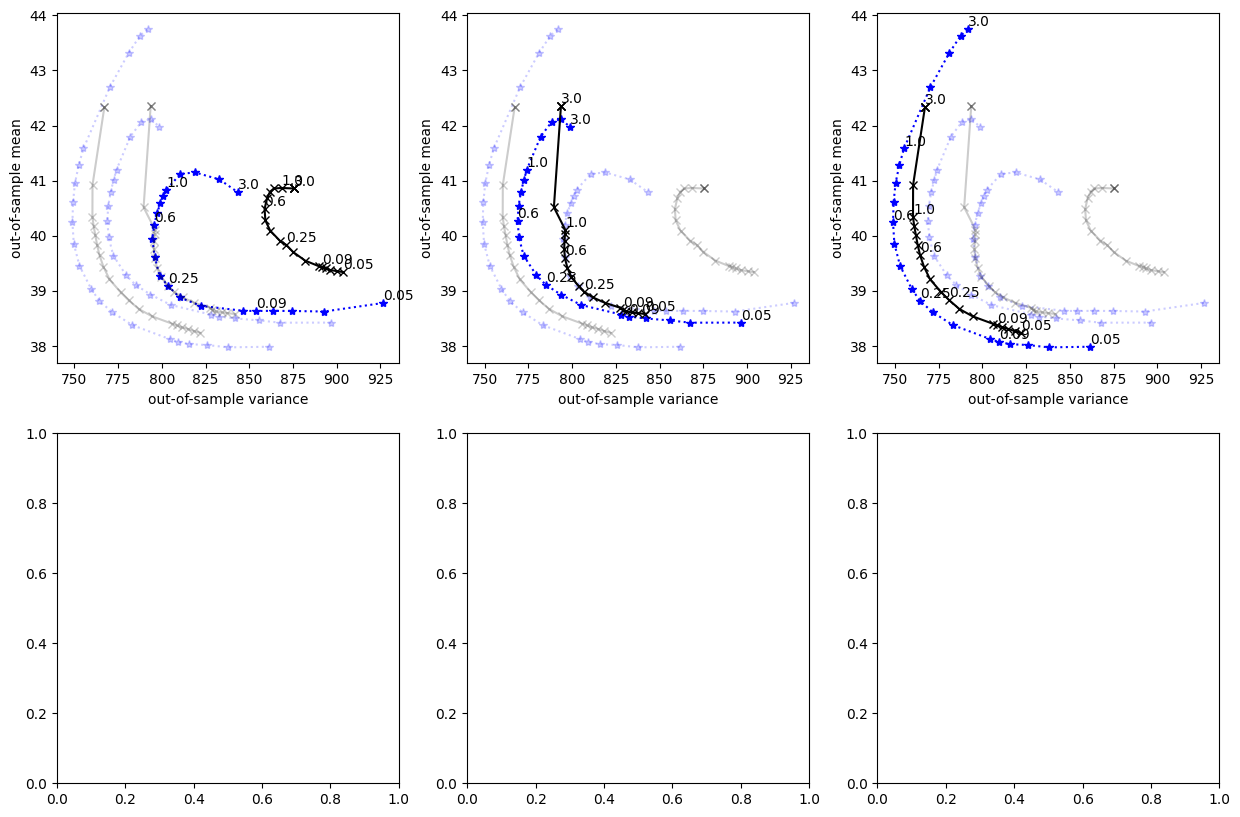

In [4]:
from mis_dro.plot import mean_variance_plot, algorithm_style

from enum import StrEnum

class NiceNameDGP(StrEnum):
    normal = "Normal DGP"
    truncated_normal = "Truncated Normal DGP"

compare_col="algorithm"
gb_col="dgp"
ncols=2
likelihood_sr = agg_df.index.get_level_values("num_likelihood_samples")
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")

TOTAL_SAMPLES = [25, 49, 100]

nrows = 2
ncols = len(TOTAL_SAMPLES)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=False, sharey=False, figsize=(5*ncols, nrows*5))

for j, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[(
        (likelihood_sr == int(np.sqrt(total_samples))) & (posterior_sr == int(np.sqrt(total_samples)))
        | (likelihood_sr == total_samples) & (posterior_sr == 1)
    )]
    df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
    gb = df.groupby(gb_col)
    for k in range(len(TOTAL_SAMPLES)):
        if j == k:
            alpha = 1.0
            is_labelled = True
        else:
            alpha = 0.2
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                    group_df.index.get_level_values("inference"),
                    group_df.index.get_level_values("posterior"),
                )
            )
            # axes[i, k].set_title(f"{NiceNameDGP[group].value} with {n_total_samples_sqrt**2} samples")
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp, inference, posterior in index_set:
                style = algorithm_style(algorithm)
                mean_variance_plot(axes[i, k], group_df.loc[algorithm, dgp, :np.inf, inference, posterior], **style, alpha=alpha, is_labelled=is_labelled)
            

fig.show()

## Solve time

In [5]:
results_df.groupby(["algorithm", "dgp", "num_total_samples"]).agg({"solve_time": ["mean", "var"]}).unstack(level="algorithm")

solve_time                                  
                               mean                   var            
algorithm                   kl_bdro our_kl_bdro   kl_bdro our_kl_bdro
dgp    num_total_samples                                             
normal 25                  0.011777    0.016711  0.000025    0.000009
       49                  0.017048    0.037144  0.000041    0.000011
       100                 0.065403    0.035802  0.001601    0.000012
       400                 0.131467    0.217713  0.006286    0.003175

In [6]:
# what is the constant G?
from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_kl_bdro_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_kl_bdro_constant("normal_gamma", theta_posterior)

dgp = "normal"
posterior = "normal_gamma"
num_observations = 10
G_constant = []
posterior_expected_kl = []
prior_expected_kl = []
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_kl_bdro_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

(0.08827544585267266, 1.925929944387236e-34)

In [7]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.16462497724528255, 0.012848186395172448)

In [8]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.78569035285864, 0.0)

In [9]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 794.3194647834051, 17.727414116711756)

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_94540/1064292950.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


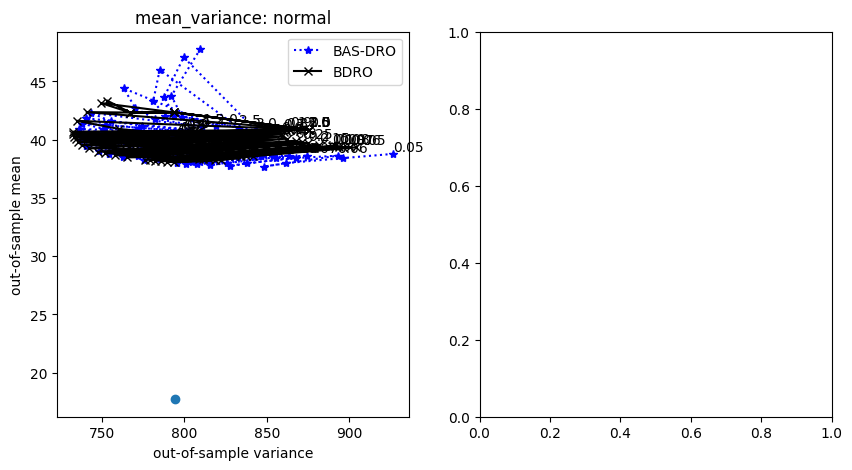

In [10]:
fig, axes = flexible_figure(agg_df, "mean_variance", compare_col="algorithm", gb_col="dgp", ncols=2)
axes[0].scatter(mean_of_variances, var_of_means)
fig.show()

epsilon | mean squared error to opt | std of mean squared error
----------
0.1 | 